In [1]:
import os
import ray
import json
import pickle
from dynaconf import Dynaconf
from tqdm.notebook import tqdm
from utils import check_path, convert_np_arrays, flatten_dict, env_creator
from ray.tune.logger import JsonLogger
from ray.rllib.algorithms.apex_dqn import ApexDQNConfig
from ray.tune.registry import register_env

pygame 2.5.2 (SDL 2.28.2, Python 3.9.16)
Hello from the pygame community. https://www.pygame.org/contribute.html


2024-04-22 17:59:17,111	WARNING __init__.py:10 -- ApexDQN has/have been moved to `rllib_contrib` and will no longer be maintained by the RLlib team. You can still use it/them normally inside RLlib util Ray 2.8, but from Ray 2.9 on, all `rllib_contrib` algorithms will no longer be part of the core repo, and will therefore have to be installed separately with pinned dependencies for e.g. ray[rllib] and other packages! See https://github.com/ray-project/ray/tree/master/rllib_contrib#rllib-contrib for more information on the RLlib contrib effort.


In [2]:
# Init Ray
ray.init(
    num_cpus=20, num_gpus=1,
    include_dashboard=False,
    _system_config={"maximum_gcs_destroyed_actor_cached_count": 200},
)


2024-04-22 17:59:19,114	INFO worker.py:1673 -- Started a local Ray instance.


Python version:,3.9.16
Ray version:,2.8.0


(RolloutWorker pid=3294397) 2024-04-22 17:59:22,946	WARNING __init__.py:10 -- ApexDQN has/have been moved to `rllib_contrib` and will no longer be maintained by the RLlib team. You can still use it/them normally inside RLlib util Ray 2.8, but from Ray 2.9 on, all `rllib_contrib` algorithms will no longer be part of the core repo, and will therefore have to be installed separately with pinned dependencies for e.g. ray[rllib] and other packages! See https://github.com/ray-project/ray/tree/master/rllib_contrib#rllib-contrib for more information on the RLlib contrib effort.
(RolloutWorker pid=3294397) /home/seventheli/anaconda3/envs/ber_gym_28/lib/python3.9/site-packages/gymnasium/envs/registration.py:531: UserWarning: WARN: Using the latest versioned environment `MiniGrid-LavaCrossingS9N1-v0` instead of the unversioned environment `MiniGrid-LavaCrossingS9N1`.
(RolloutWorker pid=3294397)   logger.warn(
(MultiAgentPrioritizedReplayBuffer pid=3294662) 2024-04-22 17:59:35,732	WARNING multi_ag

In [3]:
import mlflow
from mlflow.exceptions import MlflowException
from func_timeout import FunctionTimedOut
from botocore.exceptions import ConnectionClosedError

In [4]:
import datetime
# Config path
env_name = "MiniGrid-LavaCrossingS9N1"
run_name = int(datetime.datetime.now().timestamp())
log_path = "/home/seventheli/data/BER/experiments/logging/%s" % env_name
checkpoint_path = "/home/seventheli/data/BER/experiments/checkpoints/%s" % env_name
# Set mlflow
mlflow.set_tracking_uri("http://localhost:9999")
mlflow.set_experiment(experiment_name=env_name)
mlflow_client = mlflow.tracking.MlflowClient()

In [5]:
# Check path available
import shutil
check_path(log_path)
log_path = str(os.path.join(log_path, str(run_name)))
check_path(log_path)
if os.path.exists(log_path):
    shutil.rmtree(log_path)
check_path(log_path)
check_path(checkpoint_path)
checkpoint_path = os.path.join(checkpoint_path, str(run_name))
check_path(checkpoint_path)
if os.path.exists(checkpoint_path):
    shutil.rmtree(checkpoint_path)
check_path(checkpoint_path)

In [6]:
# Set hyper parameters
setting = "./settings/apex_minigrid.yml"
setting = Dynaconf(envvar_prefix="DYNACONF", settings_files=setting)

hyper_parameters = setting.hyper_parameters.to_dict()
hyper_parameters["logger_config"] = {"type": JsonLogger, "logdir": checkpoint_path}
hyper_parameters["env_config"] = {"id": env_name, "tile_size": 10, "img_size": 80, "max_steps": 100}

In [7]:
# Set model
import torch.nn as nn
from gymnasium.spaces.discrete import Discrete
from ray.rllib.models.torch.torch_modelv2 import TorchModelV2
from ray.rllib.models import ModelCatalog


class CNN(TorchModelV2, nn.Module):
    def __init__(self, obs_space, action_space: Discrete, num_outputs, model_config, name):
        TorchModelV2.__init__(self, obs_space, action_space, num_outputs, model_config, name)
        nn.Module.__init__(self)

        self.conv_layers = nn.Sequential(
            nn.Conv2d(obs_space.shape[-1], 32, kernel_size=3, stride=2, padding=1),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),
            nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=1),
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1),
            nn.AdaptiveMaxPool2d((1, 1)),
            nn.Flatten(1)
        )

        self._features = None

    def import_from_h5(self, h5_file: str) -> None:
        pass

    def forward(self, input_dict, state, seq_lens):
        # logging.info(input_dict)
        # logging.info(input_dict["obs"].shape)
        self._features = input_dict["obs"].float()
        # permute b/c data comes in as [B, dim, dim, channels]:
        self._features = self._features.permute(0, 3, 1, 2)
        self._features = self.conv_layers(self._features)
        return self._features.flatten(1), state

    def value_function(self):
        pass

    

hyper_parameters["hiddens"] = [256, 128]
model_name = "CNN"
ModelCatalog.register_custom_model(model_name, CNN)
hyper_parameters["model"] = {
    "custom_model": model_name,
    "no_final_linear": True,
    "fcnet_hiddens": hyper_parameters["hiddens"] + [512],
    "custom_model_config": {
        "dueling_activation": "relu",
    }
}

In [8]:
# Set run object
run_name = "APEX_%s" % env_name + "_DPER_%s" % run_name
env_example = env_creator(hyper_parameters["env_config"])
obs, _ = env_example.reset()
step = env_example.step(1)
print(env_example.action_space, env_example.observation_space)
print(env_example)
print("log path: %s; check_path: %s" % (log_path, checkpoint_path))
register_env("MiniGrid", env_creator)

Discrete(7) Box(0, 255, (80, 80, 3), uint8)
<TimeLimit<ResizeObservation<ImgObsWrapper<RGBImgObsWrapper<OrderEnforcing<PassiveEnvCheckerWGWGWGWGWGWGWGWGWG
WGVV    VR      WG
WG      VR      WG
WG      VR      WG
WG      VR      WG
WG              WG
WG      VR      WG
WG      VR    GGWG
WGWGWGWGWGWGWGWGWG>>>>>>
log path: /home/seventheli/data/BER/experiments/logging/MiniGrid-LavaCrossingS9N1/1713805160; check_path: /home/seventheli/data/BER/experiments/checkpoints/MiniGrid-LavaCrossingS9N1/1713805160


/home/seventheli/anaconda3/envs/ber_gym_28/lib/python3.9/site-packages/gymnasium/envs/registration.py:531: UserWarning: WARN: Using the latest versioned environment `MiniGrid-LavaCrossingS9N1-v0` instead of the unversioned environment `MiniGrid-LavaCrossingS9N1`.
  logger.warn(


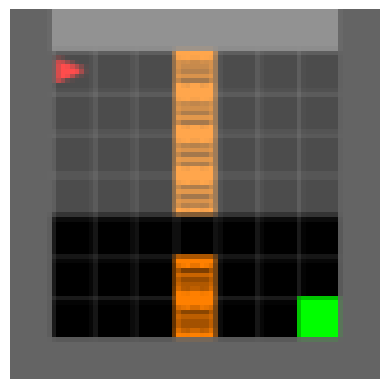

In [9]:
import matplotlib.pyplot as plt

# Plotting the image without the 4th dimension (assuming it's an alpha channel or similar)
plt.imshow(obs)
plt.axis('off')
plt.show()

In [10]:
# Set Replay Buffer
hyper_parameters["optimizer"] = {"num_replay_buffer_shards": 10}
# Set Trainer
config = ApexDQNConfig().environment("MiniGrid")
config.update_from_dict(hyper_parameters)
trainer = config.build()

2024-04-22 17:59:21,061	WARNING deprecation.py:50 -- DeprecationWarning: `rllib/algorithms/apex_dqn/` has been deprecated. Use `rllib_contrib/apex_dqn/` instead. This will raise an error in the future!
2024-04-22 17:59:21,062	WARNING deprecation.py:50 -- DeprecationWarning: `rllib/algorithms/simple_q/` has been deprecated. Use `rllib_contrib/simple_q/` instead. This will raise an error in the future!
/home/seventheli/anaconda3/envs/ber_gym_28/lib/python3.9/site-packages/ray/rllib/utils/from_config.py:197: RayDeprecationWarning: This API is deprecated and may be removed in future Ray releases. You could suppress this warning by setting env variable PYTHONWARNINGS="ignore::DeprecationWarning"
The `JsonLogger interface is deprecated in favor of the `ray.tune.json.JsonLoggerCallback` interface and will be removed in Ray 2.7.
  object_ = constructor(*ctor_args, **ctor_kwargs)


In [11]:
# Common setup
checkpoint_path = str(checkpoint_path)
# Save initial configuration
with open(os.path.join(checkpoint_path, "%s_config.pyl" % run_name), "wb") as f:
    _ = trainer.config.to_dict()
    pickle.dump(_, f)

In [12]:
mlflow_run = mlflow.start_run(run_name=run_name,
                              tags={"mlflow.user": "Local"})
# Log parameters
mlflow.log_params(hyper_parameters["replay_buffer_config"])
to_log = ['num_workers', 'double_q', 'dueling', 'lr', 'n_step', 'num_steps_sampled_before_learning_starts',
          'rollout_fragment_length', 'target_network_update_freq', 'train_batch_size', 'min_sample_timesteps_per_iteration']
mlflow.log_params(
    {key: hyper_parameters[key] for key in to_log})

In [13]:
keys_to_extract_sam = {"episode_reward_max", "episode_reward_min", "episode_reward_mean"}
keys_to_extract_sta = {"num_agent_steps_sampled", "num_agent_steps_trained"}
keys_to_extract_buf = {"add_batch_time_ms", "replay_time_ms", "update_priorities_time_ms"}

mlflow.pytorch.log_model(trainer.get_policy().model, run_name)
model_uri = "runs:/%s/model_name" % mlflow_run.info.run_id
mlflow.register_model(model_uri, run_name, tags={"episode" : 0})

/home/seventheli/anaconda3/envs/ber_gym_28/lib/python3.9/site-packages/_distutils_hack/__init__.py:33: UserWarning: Setuptools is replacing distutils.
  warnings.warn("Setuptools is replacing distutils.")
Successfully registered model 'APEX_MiniGrid-LavaCrossingS9N1_DPER_1713805160'.
2024/04/22 17:59:35 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: APEX_MiniGrid-LavaCrossingS9N1_DPER_1713805160, version 1
Created version '1' of model 'APEX_MiniGrid-LavaCrossingS9N1_DPER_1713805160'.


<ModelVersion: aliases=[], creation_timestamp=1713805175278, current_stage='None', description='', last_updated_timestamp=1713805175278, name='APEX_MiniGrid-LavaCrossingS9N1_DPER_1713805160', run_id='fe128e407ea04943badb7f13c8916b3b', run_link='', source='s3://jo-mlflow-ber/29/fe128e407ea04943badb7f13c8916b3b/artifacts/model_name', status='READY', status_message='', tags={'episode': '0'}, user_id='', version='1'>

In [17]:
for i in tqdm(range(862, 5000)):
    result = trainer.train()
    time_used = result["time_total_s"]
    try:
        sampler = result.get("sampler_results", {}).copy()
        eva = result.get("evaluation", {}).copy()
        info = result.get("info", {}).copy()
        sam = {key: sampler[key] for key in keys_to_extract_sam if key in sampler}
        sta = {key: info[key] for key in keys_to_extract_sta if key in info}
        buf = flatten_dict(info.get("replay_shard_0", {}))
        buf["est_size_bytes"] = buf["est_size_bytes"] * hyper_parameters["optimizer"]["num_replay_buffer_shards"]
        buf["est_size_gb"] = buf["est_size_bytes"] /1e9
        result['buffer'] = buf
        time_usage = info.get("learner", {}).get("time_usage", {})
        try:
            ex_info = {
                "reward_99" : calculate_adjusted_mean(result['hist_stats']['episode_reward']),
                "time_total_s": result['time_total_s']
            }
        except:
            ex_info = {}
        if eva:
            eva = {"eval_" + key: eva[key] for key in keys_to_extract_sam if key in eva}
        mlflow.log_metrics({**sam, **sta, **buf, **time_usage, **eva}, step=result["episodes_total"])
        if i % (setting.log.log * 50) == 0:
            trainer.save_checkpoint(checkpoint_path)
            mlflow.pytorch.log_model(trainer.get_policy().model, run_name)
            mlflow.register_model(model_uri, run_name, tags={
                "episode" : result["episodes_total"],
                "reward": sam["episode_reward_mean"],
            })
            mlflow.log_artifacts(log_path)
            mlflow.log_artifacts(checkpoint_path)
        if i % 10 == 0:
            tqdm.write("episode %d ; " % result["episodes_total"] +  " ".join(["%s : %f8" % (i, j)for i, j in sam.items()]))
    except FunctionTimedOut:
        tqdm.write("logging failed")
    except MlflowException:
        tqdm.write("logging failed")
    except ConnectionClosedError:
        tqdm.write("logging failed")
    with open(os.path.join(log_path, str(i) + ".json"), "w") as f:
        result["config"] = None
        json.dump(convert_np_arrays(result), f)
    if time_used >= setting.log.max_time:
        break

  0%|          | 0/4138 [00:00<?, ?it/s]

episode 154506 ; episode_reward_mean : 0.5669918 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 156890 ; episode_reward_mean : 0.5722118 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 159368 ; episode_reward_mean : 0.6189808 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 161941 ; episode_reward_mean : 0.6014408 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 164531 ; episode_reward_mean : 0.5954918 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 167019 ; episode_reward_mean : 0.5910428 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 169513 ; episode_reward_mean : 0.6338978 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 171951 ; episode_reward_mean : 0.5603868 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 174564 ; episode_reward_mean : 0.5668358 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
e

Registered model 'APEX_MiniGrid-LavaCrossingS9N1_DPER_1713805160' already exists. Creating a new version of this model...
2024/04/23 02:32:24 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: APEX_MiniGrid-LavaCrossingS9N1_DPER_1713805160, version 4
Created version '4' of model 'APEX_MiniGrid-LavaCrossingS9N1_DPER_1713805160'.


episode 187250 ; episode_reward_mean : 0.5457868 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 189886 ; episode_reward_mean : 0.6403748 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 192447 ; episode_reward_mean : 0.6178848 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 195095 ; episode_reward_mean : 0.6002888 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 197704 ; episode_reward_mean : 0.5641178 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 199985 ; episode_reward_mean : 0.6302608 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 202825 ; episode_reward_mean : 0.6609858 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 205727 ; episode_reward_mean : 0.6625098 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 208546 ; episode_reward_mean : 0.6260428 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
e

Registered model 'APEX_MiniGrid-LavaCrossingS9N1_DPER_1713805160' already exists. Creating a new version of this model...
2024/04/23 06:48:57 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: APEX_MiniGrid-LavaCrossingS9N1_DPER_1713805160, version 5
Created version '5' of model 'APEX_MiniGrid-LavaCrossingS9N1_DPER_1713805160'.


...

Registered model 'APEX_MiniGrid-LavaCrossingS9N1_DPER_1713805160' already exists. Creating a new version of this model...
2024/04/23 15:24:34 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: APEX_MiniGrid-LavaCrossingS9N1_DPER_1713805160, version 7
Created version '7' of model 'APEX_MiniGrid-LavaCrossingS9N1_DPER_1713805160'.


episode 916210 ; episode_reward_mean : 0.9396618 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 922614 ; episode_reward_mean : 0.9260478 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 928515 ; episode_reward_mean : 0.9393628 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 935431 ; episode_reward_mean : 0.9550468 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 941955 ; episode_reward_mean : 0.9296988 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 948616 ; episode_reward_mean : 0.9436778 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 954739 ; episode_reward_mean : 0.9558788 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 961620 ; episode_reward_mean : 0.9426008 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 968356 ; episode_reward_mean : 0.9330298 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
e

Registered model 'APEX_MiniGrid-LavaCrossingS9N1_DPER_1713805160' already exists. Creating a new version of this model...
2024/04/23 19:43:44 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: APEX_MiniGrid-LavaCrossingS9N1_DPER_1713805160, version 8
Created version '8' of model 'APEX_MiniGrid-LavaCrossingS9N1_DPER_1713805160'.


episode 1248482 ; episode_reward_mean : 0.9020028 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 1255208 ; episode_reward_mean : 0.9474688 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 1262064 ; episode_reward_mean : 0.9371318 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 1268709 ; episode_reward_mean : 0.9400048 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 1274425 ; episode_reward_mean : 0.9125388 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 1281249 ; episode_reward_mean : 0.9465838 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 1287908 ; episode_reward_mean : 0.9511498 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 1294249 ; episode_reward_mean : 0.8547488 episode_reward_max : 0.9638898 episode_reward_min : 0.0000008
episode 1300648 ; episode_reward_mean : 0.9496948 episode_reward_max : 0.9638898 episode_reward_min : 0.


KeyboardInterrupt



In [18]:
mlflow.log_artifacts(log_path)
mlflow.log_artifacts(checkpoint_path)
mlflow.end_run()